# Exploratory Data Analysis and Visualization

This analysis explores the employee satisfaction patterns based on key organizational factors such as salary, working hours, and department. An initial data cleaning process has already been performed and this section utilizes the processed data. 

**Note:** 
Early iterations of the exploratory analysis revealed a significant central tendency bias (a vertical artifact at $77,186) caused by a standard median imputation on missing salary records. To protect the statistical validity of the salary vs overtime hours relation, the pipeline was updated to exclude records with missing salary figures.

## Initial Data Exploration

Import the necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load the cleaned employee profiles dataset.

In [2]:
df = pd.read_csv("../data/employee_profiles_cleaned.csv")

Examine the dataset structure.

In [3]:
display(df.head())
df.info()

,employee_id,age,salary,promotion_eligible,last_training_date,department,work_experience,projects_completed,hours_worked_weekly,work_mode,last_promotion_date,satisfaction_score,overtime_hours,graduation_year,educational_background
0,E0002,41.0,64761.0,N,2023-08-15,Finance,1,8.0,53.3,hybrid,2022-05-10,6.0,8.10,1995,Architecture
1,E0005,29.0,61486.0,Y,2023-08-15,Finance,10,1.0,53.3,hybrid,2022-05-10,6.0,0.30,1991,Medicine
2,E0006,41.0,93128.0,No,2023-08-15,Hr,6,12.0,35.6,hybrid,2022-10-05,3.0,9.70,2019,Statistics
3,E0007,41.0,115377.0,Y,2023-08-15,Finance,11,13.0,33.7,hybrid,2022-05-10,7.0,1.80,1998,Mathematics
4,E0008,41.0,51543.0,Y,2023-08-15,Finance,10,8.0,40.8,hybrid,2022-05-10,6.0,6.15,2009,Philosophy


<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             63 non-null     str    
 1   age                     63 non-null     float64
 2   salary                  63 non-null     float64
 3   promotion_eligible      63 non-null     str    
 4   last_training_date      63 non-null     str    
 5   department              63 non-null     str    
 6   work_experience         63 non-null     int64  
 7   projects_completed      63 non-null     float64
 8   hours_worked_weekly     63 non-null     float64
 9   work_mode               63 non-null     str    
 10  last_promotion_date     63 non-null     str    
 11  satisfaction_score      63 non-null     float64
 12  overtime_hours          63 non-null     float64
 13  graduation_year         63 non-null     int64  
 14  educational_background  63 non-null     str    
dtypes:

### Descriptive Statistics

Generate summary statistics for some of the numerical columns.

In [4]:
numerical_stats = df[[ 'salary', 'hours_worked_weekly', 'satisfaction_score', 'projects_completed', 'overtime_hours' ]].describe()
display(numerical_stats)

,salary,hours_worked_weekly,satisfaction_score,projects_completed,overtime_hours
count,63.000000,63.000000,63.000000,63.000000,63.000000
mean,81553.111111,42.803175,5.571429,7.412698,6.261111
std,20232.682927,7.573659,2.291036,3.353549,2.158768
min,51438.000000,30.100000,1.000000,0.000000,0.300000
25%,64705.500000,36.150000,4.500000,8.000000,5.850000
50%,77186.000000,43.300000,6.000000,8.000000,6.150000
75%,98882.500000,47.100000,6.000000,8.000000,7.400000
max,118824.000000,59.400000,10.000000,15.000000,9.800000


## Satisfaction Score Pattern Identification

### Employee Satisfaction versus Salary

In [143]:
bin_edges = np.linspace(df['salary'].min(), df['salary'].max(), num=7).astype(int)
df['salary_bins'] = pd.cut(df['salary'], bins=bin_edges, include_lowest=True)
print(df['salary_bins'].value_counts().sort_index())

salary_bins
(51437.999, 62669.0]    14
(62669.0, 73900.0]      11
(73900.0, 85131.0]      12
(85131.0, 96362.0]       7
(96362.0, 107593.0]     10
(107593.0, 118824.0]     9
Name: count, dtype: int64


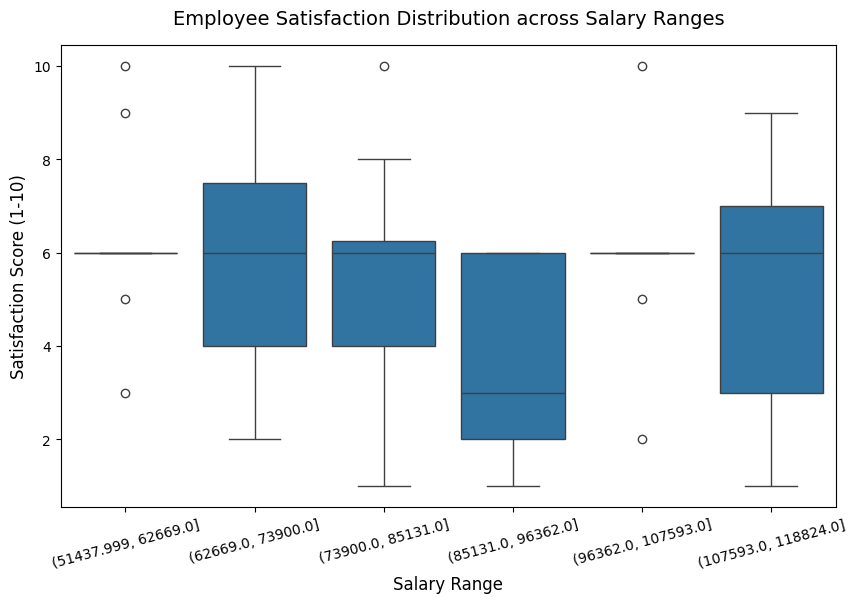

In [144]:
# Initialize a figure size that gives the bins breathing room
plt.figure(figsize=(10,6))

# Create the box plot
# Make sure to sort the data by the bins so the x-axis goes from lowest to highest
sns.boxplot(data = df.sort_values('salary_bins'), x = 'salary_bins', y = 'satisfaction_score')

# Polish the labels and presentation
plt.title('Employee Satisfaction Distribution across Salary Ranges', fontsize=14, pad=15)
plt.xlabel('Salary Range', fontsize=12)
plt.ylabel('Satisfaction Score (1-10)', fontsize=12)

# Rotate labels slightly
plt.xticks(rotation=15)

# Render the chart
plt.show()

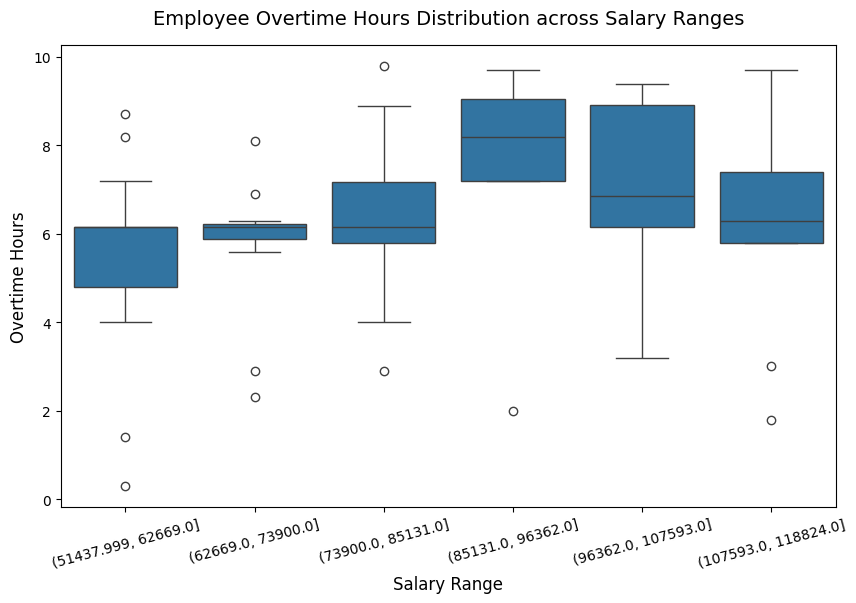

In [145]:
# Initialize a figure size that gives the bins breathing room
plt.figure(figsize=(10, 6))

# Create the box plot
# Make sure to sort the data by the bins so the x-axis goes from lowest to highest
sns.boxplot(data = df.sort_values('salary_bins'), x = 'salary_bins', y = 'overtime_hours')
#              palette = 'Blues')  # Generates a nice gradient across the bins

# Polish the labels and presentation
plt.title('Employee Overtime Hours Distribution across Salary Ranges', fontsize=14, pad=15)
plt.xlabel('Salary Range', fontsize=12)
plt.ylabel('Overtime Hours', fontsize=12)

# Rotate labels slightly
plt.xticks(rotation=15)

# Render the chart
plt.show()

In [146]:
# Group by salary bins and look at the average tenure, overtime, and satisfaction
salary_story = df.groupby('salary_bins', observed=False).agg(
    avg_experience    = ('work_experience', 'mean'),
    median_overtime   = ('overtime_hours', 'median'),
    q3_overtime       = ('overtime_hours', lambda x: x.quantile(0.75)),
    median_satisfaction = ('satisfaction_score', 'median'),
    low_satisfaction_q1 = ('satisfaction_score', lambda x: x.quantile(0.25)),
    employee_count    = ('employee_id', 'count')
).sort_index()

salary_story

,avg_experience,median_overtime,q3_overtime,median_satisfaction,low_satisfaction_q1,employee_count
salary_bins,,,,,,
"(51437.999, 62669.0]",9.928571,6.15,6.150,6.0,6.0,14
"(62669.0, 73900.0]",9.090909,6.15,6.225,6.0,4.0,11
"(73900.0, 85131.0]",11.250000,6.15,7.175,6.0,4.0,12
"(85131.0, 96362.0]",12.285714,8.20,9.050,3.0,2.0,7
"(96362.0, 107593.0]",6.200000,6.85,8.925,6.0,6.0,10
"(107593.0, 118824.0]",10.000000,6.30,7.400,6.0,3.0,9


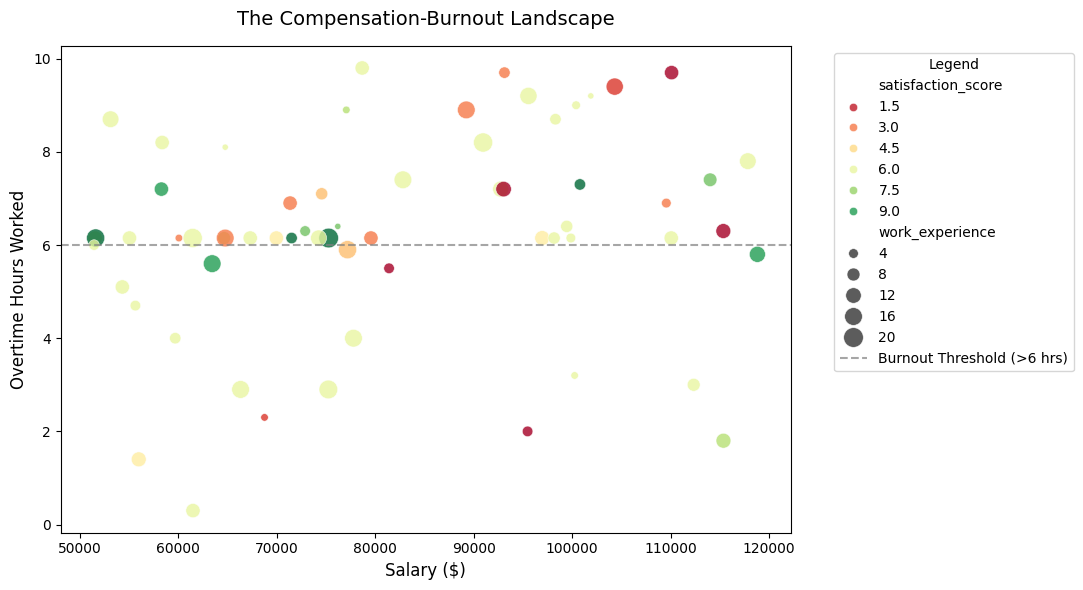

In [147]:
plt.figure(figsize=(11, 6))

# Create a scatter plot showing the interaction of overtime hours, and salary, colored by satisfaction score, and sized by experience
sns.scatterplot(
    data=df,
    x='salary',
    y='overtime_hours',
    hue='satisfaction_score',
    palette='RdYlGn', # Red (Low Sat) to Yellow to Green (High Sat)
    alpha=0.8,
    size='work_experience', # Larger dots show more tenured employees
    sizes=(20, 200)
)

# Highlight the six-hour danger threshold
plt.axhline(y=6, color='grey', linestyle='--', alpha=0.7, label='Burnout Threshold (>6 hrs)')

plt.title('The Compensation-Burnout Landscape', fontsize=14, pad=15)
plt.xlabel('Salary ($)', fontsize=12)
plt.ylabel('Overtime Hours Worked', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Legend')
plt.tight_layout()
plt.show()

### Employee Satisfaction versus Overtime Hours

Categorize the overtime hours into equal sized bins.

In [148]:
bin_edges = np.linspace(0, df['overtime_hours'].max(), num=7)
df['overtime_bins'] = pd.cut(df['overtime_hours'], bins=bin_edges, include_lowest=True)
print(df['overtime_bins'].value_counts().sort_index())

overtime_bins
(-0.001, 1.633]     2
(1.633, 3.267]      7
(3.267, 4.9]        3
(4.9, 6.533]       27
(6.533, 8.167]     11
(8.167, 9.8]       13
Name: count, dtype: int64


Majority of the employees work five or more hours of overtime. Create a boxplot of satisfaction scores vs overtime hours to see how it changes for each bin.

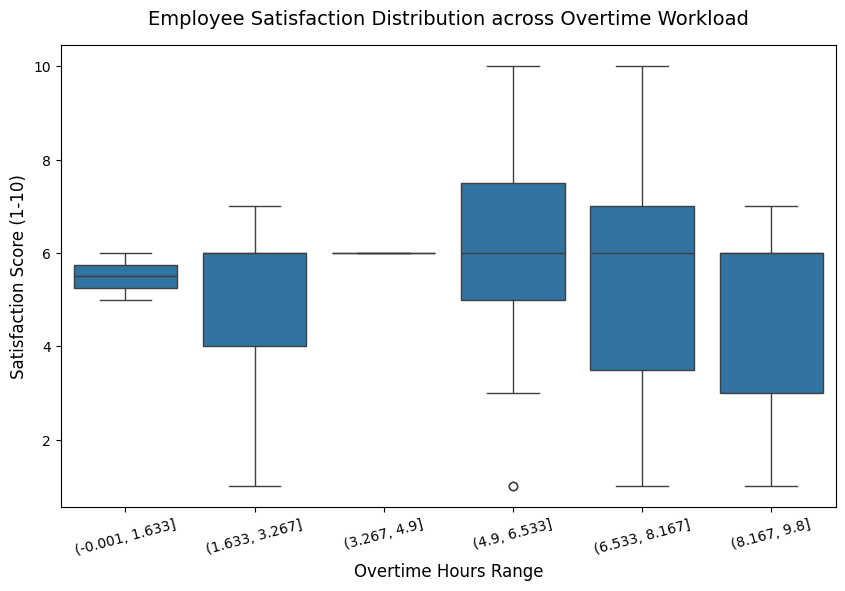

In [149]:
# Initialize a figure size that gives the bins breathing room
plt.figure(figsize=(10, 6))

# Create the box plot
# Make sure to sort the data by the bins so the x-axis goes from lowest to highest
sns.boxplot(data = df.sort_values('overtime_bins'), x = 'overtime_bins', y = 'satisfaction_score')

# Polish the labels and presentation
plt.title('Employee Satisfaction Distribution across Overtime Workload', fontsize=14, pad=15)
plt.xlabel('Overtime Hours Range', fontsize=12)
plt.ylabel('Satisfaction Score (1-10)', fontsize=12)

# Rotate labels slightly
plt.xticks(rotation=15)

# Render the chart
plt.show()

The satisfaction score drops as employees work 6.5 hrs or more overtime. 
Create a scatter plot of satisfaction score versus overtime hours. 

<Axes: xlabel='overtime_hours', ylabel='satisfaction_score'>

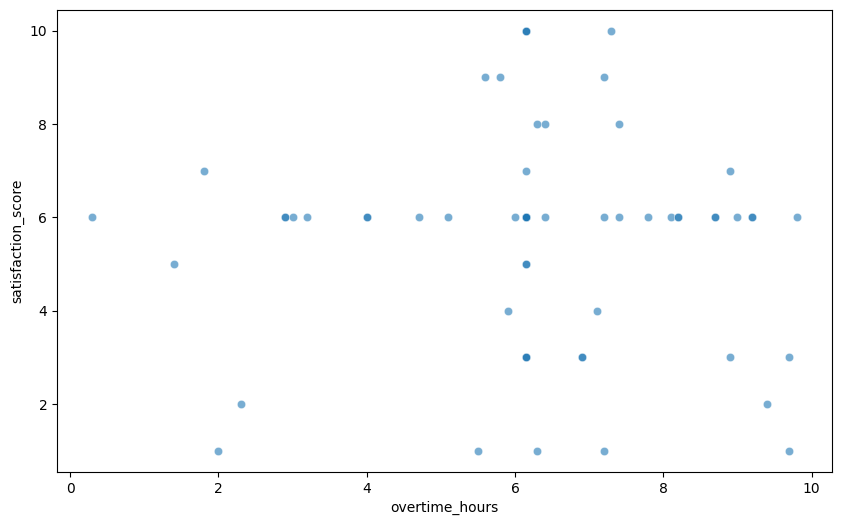

In [150]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='overtime_hours', y='satisfaction_score', alpha=0.6)

### Employee Satisfaction versus Work Mode

Display the number of employees by work mode.

In [151]:
df['work_mode'].value_counts()

work_mode
hybrid     34
remote     20
on-site     9
Name: count, dtype: int64

Create a boxplot of the satisfaction score by `work_mode`.

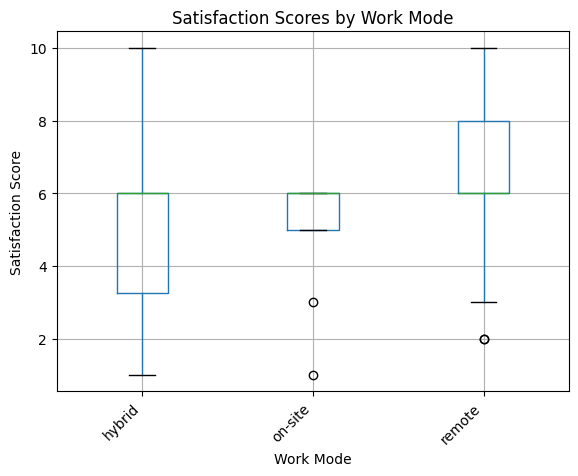

In [152]:
df.boxplot(column='satisfaction_score',by='work_mode')
# Remove the duplicate title added by boxplot
plt.suptitle('')
# Rotate the x-axis labels
plt.xticks(rotation=45, ha='right')
plt.xlabel('Work Mode')  # Add x-axis label
plt.ylabel('Satisfaction Score')  # Add y-axis label
plt.title('Satisfaction Scores by Work Mode')
plt.show()


While the median satisfaction score is the same for all three work modes, the distribution of score is higher for remote employees than hybrid or on-site employees.

### Employee Satisfaction versus Educational Background

Calculate average satisfaction scores by educational background.

In [153]:
satisfaction_scores_by_educational_background = df.groupby(['educational_background'])['satisfaction_score'].agg('mean').round(2)
print(satisfaction_scores_by_educational_background) 

educational_background
Architecture               6.00
Biology                    6.50
Business Administration    4.33
Chemistry                  7.25
Computer Science           6.67
Economics                  4.20
Engineering                5.00
Law                        7.00
Linguistics                5.50
Mathematics                6.67
Medicine                   6.00
Philosophy                 6.60
Physics                    6.00
Political Science          6.00
Psychology                 4.67
Statistics                 3.33
Name: satisfaction_score, dtype: float64


Visualize the average satisfaction scores by educational background.

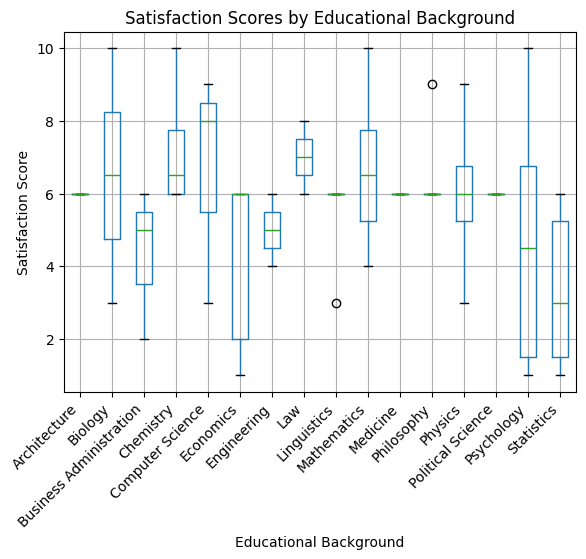

In [154]:
df.boxplot(column='satisfaction_score',by='educational_background')
# Remove the duplicate title added by boxplot
plt.suptitle('')
# Rotate the x-axis labels
plt.xticks(rotation=45, ha='right')
plt.xlabel('Educational Background')  # Add x-axis label
plt.ylabel('Satisfaction Score')  # Add y-axis label
plt.title('Satisfaction Scores by Educational Background')
plt.show()

##### Micro-Cohort (Statistics)

Explore the workforce data for employees who have a statistics background.

In [155]:
# Filter for employees with a statistics background
stats_workers = df[(df['educational_background'] == 'Statistics')]

# Display the overtime hours for these employees
stats_workers['overtime_hours']

2     9.70
9     6.15
12    5.50
27    9.70
33    8.20
39    2.90
Name: overtime_hours, dtype: float64

Majority of the employees who have a statistics background are working more than 6 hours overtime, which is consistent with the initial conclusion made.

### Employee Satisfaction by Department

Plot the average satisfaction scores by `department`.

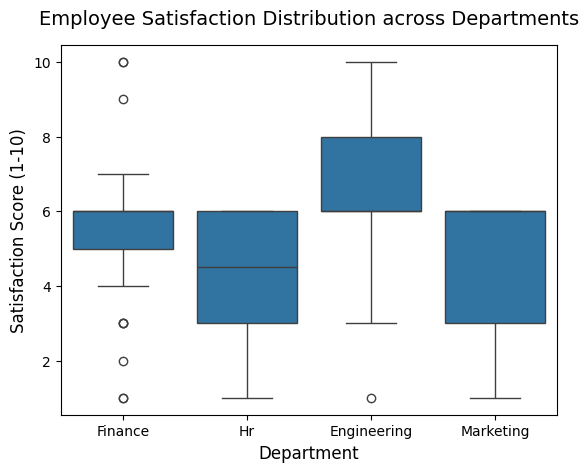

In [ ]:
#Create the box plot
sns.boxplot(data = df, x = 'department', y = 'satisfaction_score')

# Polish the labels and presentation
plt.title('Employee Satisfaction Distribution across Departments', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Satisfaction Score (1-10)', fontsize=12)

# Render the chart
plt.show()

All three departments, but `HR` has a median satisfaction score of 6. HR department's median satisfaction score is 4.5. `Finance` and `Marketing`'s satisfaction score distribution is to the left of (lower than)the median of 6.0. To see if this might be related to the overtime hours, create a boxplot of overtime hours by department.

Text(0, 0.5, 'Overtime Hours')

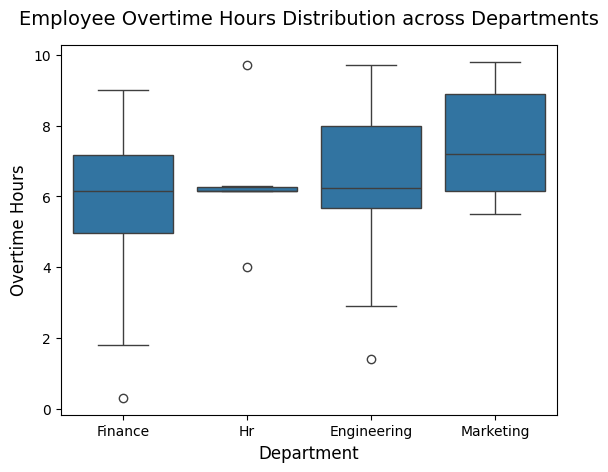

In [ ]:
sns.boxplot(data = df, x = 'department', y = 'overtime_hours')
# Polish the labels and presentation
plt.title('Employee Overtime Hours Distribution across Departments', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Overtime Hours', fontsize=12)

The median overtime hours for all departments but `Marketing` is 6.0. The whole distribution of overtime hours for the marketing department is higher than the company medion of 6.0 per week. This might be a big contributing factor to the lower dissatisfaction of employees in this department. Despite the mid to higher overtime hours per week for the Engineering department, their satisfaction score scales higher than other departments. Let's check remote work is a contributing factor.

Create a bar chart of work mode by department.

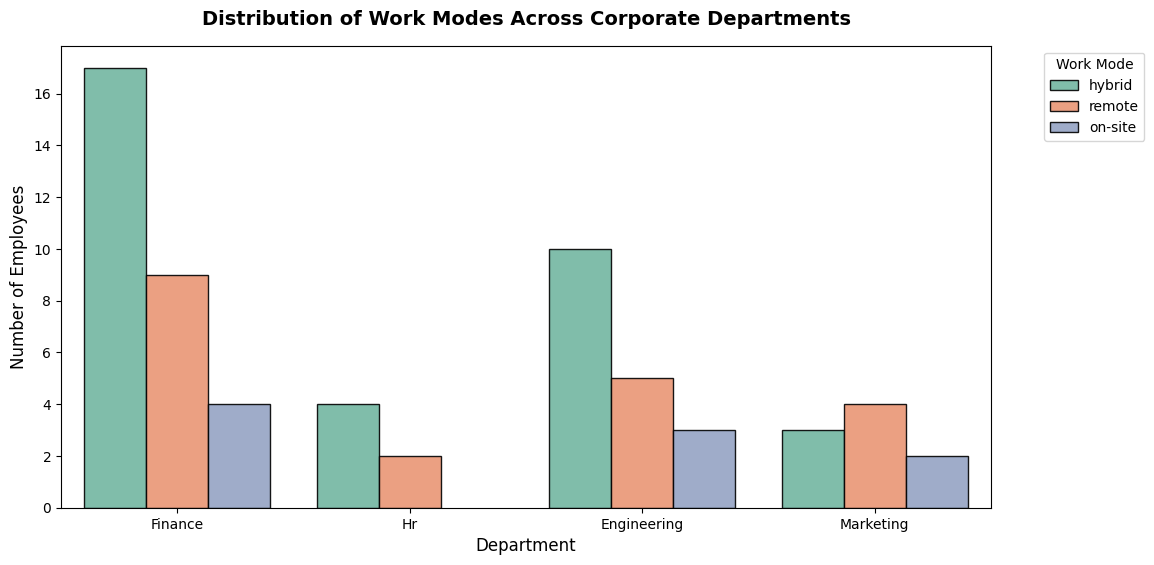

In [ ]:
plt.figure(figsize=(12, 6))

# Create a grouped count plot showing Work Mode distributions within each Department
sns.countplot(data=df, x='department', hue='work_mode',
    palette='Set2', edgecolor='black',alpha=0.9)

plt.title('Distribution of Work Modes Across Corporate Departments', fontsize=14, pad=15, weight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Work Mode', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Engineering does not seem to have a bigger percentage of remote workers. Next, let's look at some statistics to see if salary might be a contributing factor to high satisfaction in this department and others.

In [174]:
# Group by department to check the exact interaction of all the factors we have been theorizing about
dept_validation = df.groupby('department').agg(
    headcount           = ('employee_id', 'count'),
    median_satisfaction = ('satisfaction_score', 'median'),
    median_overtime     = ('overtime_hours', 'median'),
    avg_salary          = ('salary', 'mean'),
    weekly_hours       = ('hours_worked_weekly', 'mean'),
    pct_remote          = ('work_mode', lambda x: (x == 'remote').mean() * 100)
).round(1).sort_values(by='median_satisfaction', ascending=False)

print("--- DEPARTMENT DIAGNOSTIC MATRIX ---")
dept_validation

--- DEPARTMENT DIAGNOSTIC MATRIX ---


,headcount,median_satisfaction,median_overtime,avg_salary,weekly_hours,pct_remote
department,,,,,,
Engineering,18,6.0,6.2,77961.2,42.7,27.8
Finance,30,6.0,6.2,83224.9,43.0,30.0
Marketing,9,6.0,7.2,86756.4,41.0,44.4
Hr,6,4.5,6.2,76164.7,44.9,33.3


Create a boxplot of salary by department.

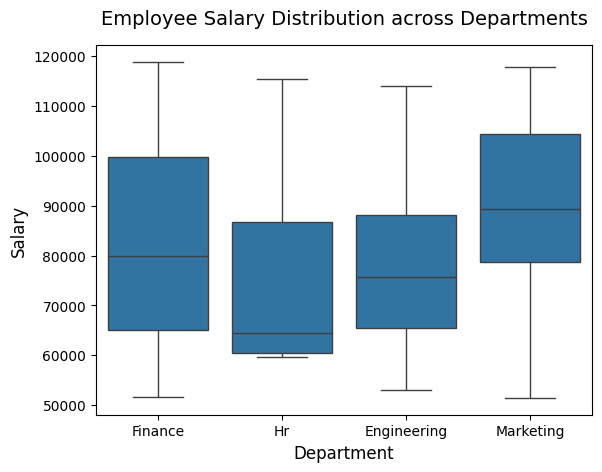

In [175]:
sns.boxplot(data = df, x = 'department', y = 'salary')

# Polish the labels and presentation
plt.title('Employee Salary Distribution across Departments', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Salary', fontsize=12)

plt.show()

HR department has the lowest salary median and distribution which seems to be contributing to their lowest satisfaction. Marketing department has the highest salary and the highest remote work percentage, which supports our theory that their low satisfaction is due to the high overtime worked. Let's look at one final measure, hours worked weekly by department.

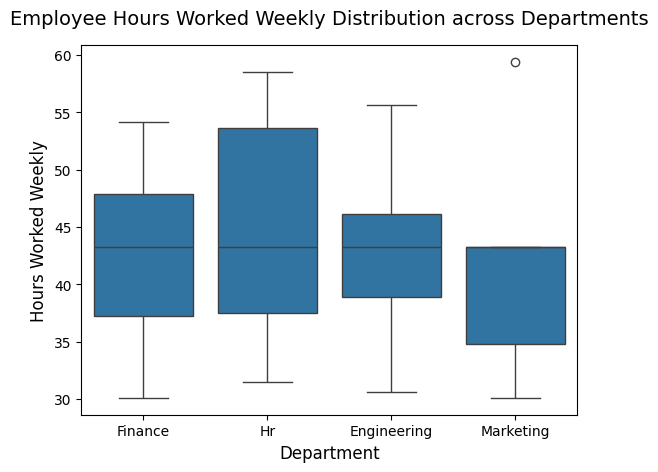

In [176]:
# Create a box plot of hours worked weekly by department
sns.boxplot(data = df, x = 'department', y = 'hours_worked_weekly')

# Polish the labels and presentation
plt.title('Employee Hours Worked Weekly Distribution across Departments', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Hours Worked Weekly', fontsize=12)

plt.show()

HR department exployees have the highest weekly hours, added to the lowest salary range makes the low satisfaction in this department. An interesting fact is the weekly hours of Marketing department. These employees seem to have the lowest weekly hours, but the highest overtime hours. It is important to understand for how many hours a week these employees are being contracted and compensated, and how the marketing projects are managed. The dataset is currently lacking this information. Understanding the reason for the high overtime hours of these workers is necessary to improve the overall satisfaction in this department. 

---

## Strategic Insights and Executive Summary

To validate the macro-level insights observed across the general workforce population, the dataset was aggregated by department to explore how compensation structures, workplace flexibility, and workload pressure interact at a localized level. 

The empirical diagnostic matrix reveals that different operational tracks face entirely distinct structural risks, proving that an enterprise human capital strategy cannot rely on blanket policies:

| Department | Headcount | Median Satisfaction | Median Weekly Overtime | Average Salary | Weekly Hours | Remote Workforce % |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Engineering** | 18 | **6.0** | 6.2 hrs | \$77,961 | 42.7 hrs | 27.8% |
| **Finance** | 30 | **6.0** | 6.2 hrs | \$83,225 | 43.0 hrs | 30.0% |
| **Marketing** | 9 | **6.0** | **7.2 hrs** | **\$86,756** | **41 hrs** | **44.4%** |
| **HR** | 6 | **4.5** | 6.2 hrs | **\$76,164** | **44.9 hrs** | 33.3% |

### 🔍 Core Departmental Diagnostics & Root-Cause Analysis

#### 1. The HR Warning Sign (Low Pay & Extreme Work Volume)
The HR department is our biggest risk area, with a satisfaction score dropping down to **4.5**. While their average salary looks close to Engineering on paper, the salary boxplot reveals that their median salary is actually the lowest in the company at around **$65k**.

At the same time, their weekly hours boxplot shows a massive range. HR's 25th to 75th percentile spans from 35 to roughly 54 hours a week. To put that in perspective, the 75th percentile for every other department tops out at 47 hours or lower. This means a huge chunk of the HR team is underpaid while pulling the heaviest total work volumes in the company, driving their low satisfaction.

#### 2. The Marketing Paradox 
Marketing represents a critical organizational paradox. On paper, it is the most highly compensated segment (\$86.7k average) and enjoys the highest degree of remote work flexibility (44.4%). However, its median satisfaction remains capped at a mediocre 6.0. 

Cross-referencing organizational distributions reveals the root cause: Marketing exhibits a compressed absolute work volume (lowest at 41 hrs weekly) but the highest median overtime at **7.2 hours per week**—significantly surpassing the 6-hour organizational burnout horizon. The boxplots solve this riddle. Marketing has the lowest total weekly hours, but the highest median overtime at 7.2 hours a week—well past our 6-hour burnout threshold. This tells us their workload is likely highly cyclical, driven by major campaign launches or crunch periods. We do not have data on their work structure, it would be important to collect more information on that. Regardless, this is a huge takeaway: financial premiums and working from home fail to protect people from burning out if their overtime hours aren't managed.

#### 3. Engineering & Finance Steady-State Realities
* **Engineering:** Counter to the initial expectation that engineers might be happier because of higher pay, the data showed the opposite. Engineering actually has a lower average salary ($77.9k) and the least remote flexibility (27.8%). The fact that their satisfaction holds steady at 6.0 and up might be due to their overtime being kept at the standard 6.2 hours and their weekly hours being tightly contained, deparment culture, and/or satisfaction from work impact.

* **Finance:** As our largest group (30 employees), Finance represents the steady pulse of the company. They match the macro trends, hovering right on that 6-hour overtime cliff with a median satisfaction score of 6.0. However, the boxplots reveal that 6.0 also represents the 75th percentile of their satisfaction score, meaning a significant majority (75%) of the department scores a 6.0 or lower. Certain measures—such as offering more remote flexibility or checking for a market adjustment in compensation—could be critical levers to pull to help drive the overall satisfaction up for this department.


---

## 🛠️ Next Steps: Statistical Analysis
Now that the data is cleaned up, the visual anomalies are gone, and we have a clear picture of these departmental trends, the next step is to run the actual math and see if these insights hold up statistically:

1. **Categorical Independence Testing (Chi-Square):** Run two separate tests of independence to see if our categorical segments have a real, mathematically significant relationship: 

    * **Overtime Threshold vs. Attrition:** To prove if crossing that 6-hour overtime cliff is a genuine statistical driver for why employees leave the company.
    * **Work Mode vs. High Overtime:** To see if an employee's work environment (Remote, Hybrid, In-Office) structurally changes their likelihood of overworking, or if overtime is a systemic issue across the whole company.

2. **Variance Testing (ANOVA):** Implement analysis of variance checking across segmented department groups to confirm if the drop in HR's satisfaction score meets the threshold of statistical significance or represents localized variance.